# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name:

Sciper number:

#### Group Member 2:
Name:

Sciper number:

#### Group Member 3:
Name:

Sciper number:

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [ ]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s] = ??? # TODO (unnormalized update)
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = ??? # TODO: normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [ ]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [ ]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [ ]:
solver = MDPsolver(gridworld)
solver.value_iteration()

In [ ]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [ ]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([ ??? for s in range(pi.shape[0])])) # TODO
    return variation

In [ ]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [ ]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            policy[h, state, :] = ??? # TODO (unnormalized)
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = ??? # TODO: fallback to a uniform distribution
            else:
                policy[h, state, :] = ??? # TODO: normalize

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=???) # TODO
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += ??? # TODO

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += ??? # TODO
            
            # Update empirical transition estimate
            estimated_transitions[h,state,a,:] = ??? # TODO
            
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = ???

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            Q_new[h] = ??? # TODO

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = ??? # TODO
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [ ]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

In [ ]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [1]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8

  Using cached gym-0.25.2.tar.gz (734 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.25.2-py3-none-any.whl size=852394 sha256=d49e99caaa59dcfcfac8993d6f04a06cb58c1559e700b3ec40f4be1e30f79bb2
  Stored in directory: /Users/talizou/Library/Caches/pip/wheels/e6/45/45/4e6c047a424cfc385198309d6c6f32c39866f256f25d4048bf
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.26.2
    Uninstalling gym-0.26.2:
      Successfully uninstalled gym-0.26.2
  Attempting uninstall: gym-notices
    Found existing installation: gym-notices 0.1.0
    Uninstalling gym-notices-0.1.0:
      Successfully uninstalled gym-notices-0.1.0


In [1]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [3]:
env = gym.make('CartPole-v0')
env.seed(0)

/opt/anaconda3/lib/python3.12/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/opt/anaconda3/lib/python3.12/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/anaconda3/lib/python3.12/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/anaconda3/lib/python3.12/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.res

[0]

In [4]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [5]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

Ideally, we would like our baseline to be "close" to the value function at the current state. This is because the variance of the policy gradient estimator is reduced when the baseline is close to the value function, as it helps to cancel out some of the noise in the returns. The baseline should not depend on the action taken, as we don't want it to modify the expectation of the gradient. 

First Baseline: we say the cart's velocity should be close to zero, as high velocity is obviously not stable.

value = 25 - 5 * (v^2)

which penalizes high velocities. We use a (1 - x^2) shape for more stable gradient than absolute value. The factor 50 is chosen so the baseline has similar scale as the retunrs and therefor reduces the variance. The factor 4 is taken as normalization to have baseline close to 0 when velocity is around 4, which is mostly the maximal velocity observed in simulations.

Second Baseline: cart should stay near the center

value = 50 * (1 - (cart_position/2.4)^2)

The normalization here ensures that the baseline is zero when the cart reaches the boundaries, and maximal at the center. This design aligns well with the environment’s goal of keeping the cart near the center of the track. The coefficient 50 was selected like before to provide a good variance-reducing effect while still maintaining sensitivity to the reward structure.


Empirically, we observe that Baseline 1 and 2 consistently lead to faster and more stable learning, compared to naïve baseline, reaching optimal reward levels quickly and maintaining them throughout training. 

In [86]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

#def baseline_1(state): # motion-based: small, shrinks under instability
  cart_velocity = state[1]
  angular_velocity = state[3]
  value = 25 - 5 * (cart_velocity**2)
  return max(value, 0) # prevent negative values

def baseline_2(state): # location-based: small, peaks at center
  cart_position = state[0]
  value = 50 * (1 - (cart_position/2.4)**2)
  return value

#def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  cart_velocity = state[1]
  angular_velocity = state[3]
  value = 50 * (0.1 - (angular_velocity)**2)  
  return max(value, 0)  # prevent negative values

def lookahead_baseline(state):
  angular_velocity = state[3]
  value = 20 * (0.1 - (angular_velocity)**2)  
  return max(value, 0)

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  cart_velocity = state[1]
  value = 20 * (1 - (cart_velocity/3.0)**2)  
  return max(value, 0)  # prevent negative values


# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [71]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 84.89
Episode 200	Average Score: 195.72
Episode 300	Average Score: 139.81
Episode 400	Average Score: 167.48
Episode 500	Average Score: 188.59
Episode 600	Average Score: 189.20
Episode 700	Average Score: 198.46
Episode 800	Average Score: 200.00
Episode 900	Average Score: 200.00
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 190.84
Episode 1400	Average Score: 195.35
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 198.73
Episode 1800	Average Score: 180.65
Episode 1900	Average Score: 200.00


In [87]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 33.74
Episode 200	Average Score: 166.52
Episode 300	Average Score: 171.39
Episode 400	Average Score: 112.28
Episode 500	Average Score: 128.00
Episode 600	Average Score: 194.45
Episode 700	Average Score: 200.00
Episode 800	Average Score: 200.00
Episode 900	Average Score: 200.00
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 194.20
Episode 1300	Average Score: 200.00
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 200.00
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 200.00


In [73]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



Episode 100	Average Score: 16.04
Episode 200	Average Score: 27.66
Episode 300	Average Score: 119.30
Episode 400	Average Score: 200.00
Episode 500	Average Score: 200.00
Episode 600	Average Score: 200.00
Episode 700	Average Score: 200.00
Episode 800	Average Score: 200.00
Episode 900	Average Score: 197.73
Episode 1000	Average Score: 192.91
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 200.00
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 200.00
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 200.00


In [74]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT43: run REINFORCE and the proposed baseline (naïve baseline)
policy_baseline_naive = Policy().to(device)
optimizer_baseline_naive = optim.Adam(policy_baseline_naive.parameters(), lr=1e-2)
scores_baseline_naive = reinforce_rwd2go_baseline(policy_baseline_naive, optimizer_baseline_naive, baseline=naive_baseline, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 20.75
Episode 200	Average Score: 110.37
Episode 300	Average Score: 171.74
Episode 400	Average Score: 191.44
Episode 500	Average Score: 196.59
Episode 600	Average Score: 200.00
Episode 700	Average Score: 200.00
Episode 800	Average Score: 194.54
Episode 900	Average Score: 193.05
Episode 1000	Average Score: 196.58
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 200.00
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 200.00
Episode 1800	Average Score: 197.75
Episode 1900	Average Score: 174.96


In [75]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT43: run REINFORCE and the proposed baseline (naïve baseline)
policy_baseline_look = Policy().to(device)
optimizer_baseline_look = optim.Adam(policy_baseline_look.parameters(), lr=1e-2)
scores_baseline_look = reinforce_rwd2go_baseline(policy_baseline_look, optimizer_baseline_look, baseline=lookahead_baseline, early_stop=False, n_episodes=2000)

Episode 100	Average Score: 43.16
Episode 200	Average Score: 87.91
Episode 300	Average Score: 132.48
Episode 400	Average Score: 160.60
Episode 500	Average Score: 196.38
Episode 600	Average Score: 178.05
Episode 700	Average Score: 157.05
Episode 800	Average Score: 188.22
Episode 900	Average Score: 186.86
Episode 1000	Average Score: 186.39
Episode 1100	Average Score: 163.08
Episode 1200	Average Score: 190.41
Episode 1300	Average Score: 142.43
Episode 1400	Average Score: 119.66
Episode 1500	Average Score: 157.74
Episode 1600	Average Score: 188.12
Episode 1700	Average Score: 145.66
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 179.36


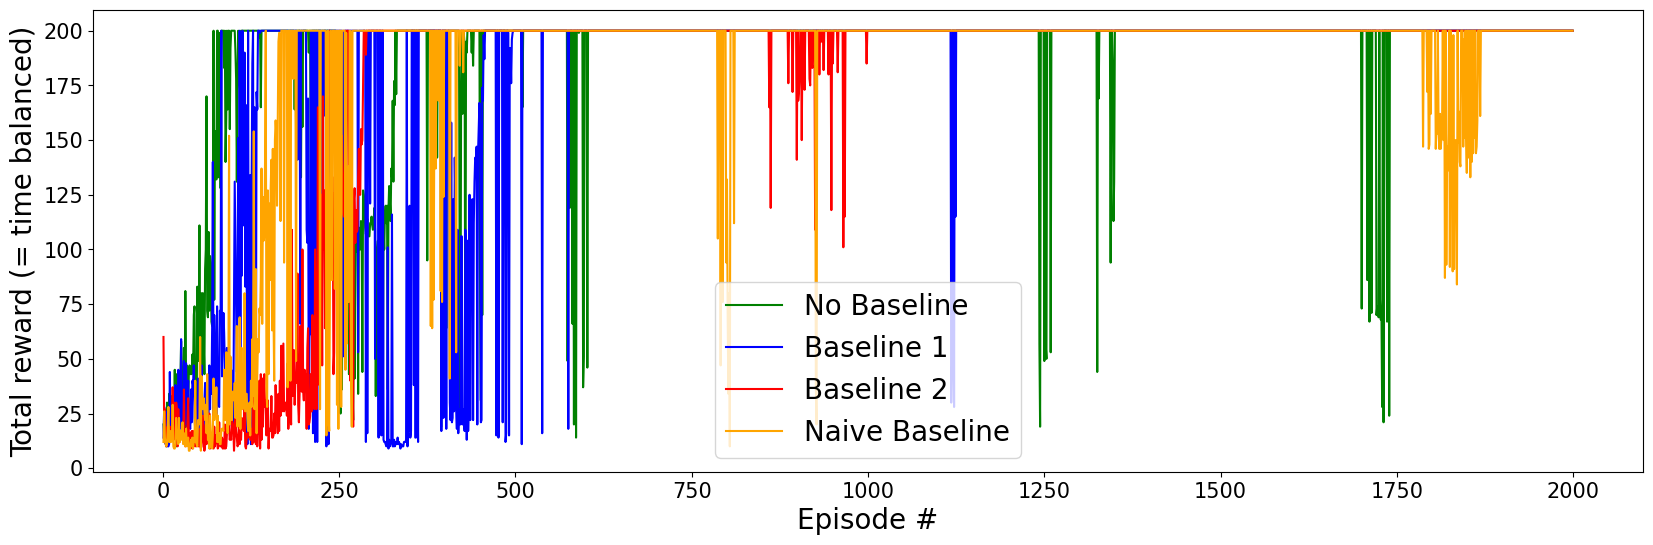

In [88]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels

ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')
ax.plot(np.arange(1, len(scores_baseline_naive) + 1), scores_baseline_naive, color='orange', label='Naive Baseline')
#ax.plot(np.arange(1, len(scores_baseline_look) + 1), scores_baseline_look, color='purple', label='Lookahead Baseline')


# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq \sqrt{ H^3 SA T \log( T H)}$$

QUESTION 1:

The policy is a Gaussian policy:

$$
\pi_{\mu, \Sigma}(a \mid s) = \mathcal{N}(a \mid \mu, \Sigma),
$$

with:
- $\mu \in \mathbb{R}^d$ the mean,
- $\Sigma \in \mathbb{R}^{d \times d}$ the covariance matrix.

We want to compute the policy gradient of the expected return $J(\pi_{\mu, \Sigma})$ with respect to both $\mu$ and $\Sigma$.

To do that, we use the standard log-likelihood trick (from REINFORCE):

$$
\nabla_\theta J(\pi_\theta) = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(a \mid s) \cdot Q^\pi(s, a) \right]
$$



Gradient with respect to the mean $\mu$:

The log of a Gaussian distribution is:

$$
\log \pi_{\mu,\Sigma}(a) = -\frac{1}{2}(a - \mu)^T \Sigma^{-1} (a - \mu) + \text{const}
$$

Taking the gradient of this log-likelihood with respect to $\mu$:

$$
\nabla_\mu \log \pi_{\mu,\Sigma}(a) = \Sigma^{-1}(a - \mu)
$$

So the full gradient of $J$ with respect to $\mu$ is:

$$
\nabla_\mu J(\pi_{\mu, \Sigma}) = \mathbb{E}_{\pi_{\mu, \Sigma}} \left[ \Sigma^{-1}(a - \mu) \cdot Q^\pi(s, a) \right]
$$


Gradient with respect to the covariance matrix $\Sigma$:

The full log-likelihood also includes a term from the determinant of $\Sigma$:

$$
\log \pi_{\mu,\Sigma}(a) = -\frac{1}{2} \left[ \log \det(2\pi \Sigma) + (a - \mu)^T \Sigma^{-1} (a - \mu) \right]
$$

Taking the gradient with respect to $\Sigma$, we get:

$$
\nabla_\Sigma \log \pi_{\mu,\Sigma}(a) = \frac{1}{2} \left[ \Sigma^{-1}(a - \mu)(a - \mu)^T \Sigma^{-1} - \Sigma^{-1} \right]
$$

So the gradient of the objective with respect to $\Sigma$ becomes:

$$
\nabla_\Sigma J(\pi_{\mu, \Sigma}) = \mathbb{E}_{\pi_{\mu, \Sigma}} \left[ \frac{1}{2} \left( \Sigma^{-1}(a - \mu)(a - \mu)^T \Sigma^{-1} - \Sigma^{-1} \right) \cdot Q^\pi(s, a) \right]
$$


###  Question 2

We are asked to prove the inequality:

$$
\sum_{t=1}^T \sum_{h=1}^H \frac{1}{N^t_h(s^t_h, a^t_h) + 1} \leq SA \log(TH)
$$

Here:
- $N^t_h(s, a)$ is the number of times state-action pair $(s, a)$ has been visited at step $h$ up to episode $t$,
- $(s^t_h, a^t_h)$ is the state-action pair encountered at step $h$ of episode $t$.

Each time a specific pair $(s, a)$ is visited at step $h$, we add a term of the form:

$$
\frac{1}{N^t_h(s, a) + 1}
$$

to the sum. We note that this is always smaller than $\frac{1}{N^t_h(s, a)}$, so the inequality becomes even easier to satisfy.

Let’s reorganize the sum by grouping it over the actual state-action pairs. For each $(s, a)$, we consider the total number of times it is visited (across all $h$ and $t$). Since the total number of time steps across $T$ episodes and $H$ steps is $TH$, the number of such visits is at most $TH$.

Then, for each fixed $(s,a)$, the sequence of visit counts contributes a harmonic sum:

$$
\sum_{i=1}^{n_{s,a}} \frac{1}{i+1} \leq \sum_{i=1}^{TH} \frac{1}{i} \leq \log(TH + 1) 
$$

The last inequality comes from approximating the harmonic sum using integrals : $\sum_{k=1}^{n} \frac{1}{k} \leq \int_1^{n+1} \frac{1}{x} \, dx = \log(n+1)$
Summing over all $SA$ distinct pairs, we get:

$$
\sum_{t=1}^T \sum_{h=1}^H \frac{1}{N^t_h(s^t_h, a^t_h) + 1}
\leq SA (\log(TH + 1))
$$

So for $TH$ big enough, we can say $TH + 1 \approx TH$ and we conclude:

$$
\sum_{t=1}^T \sum_{h=1}^H \frac{1}{N^t_h(s^t_h, a^t_h) + 1} \leq SA \log(TH)
$$

as required.


### Question 3

We begin by noting that the bonus is large when the state-action pair is rarely visited, and shrinks as $N^t_h(s,a)$ grows.

To bound the sum of all bonuses received over $T$ episodes and $H$ steps per episode, we can apply the **Cauchy–Schwarz inequality**. Let’s define:

$$
x_{t,h} := \frac{1}{\sqrt{N^t_h(s^t_h, a^t_h)}}, \quad \text{so} \quad \mathrm{bonus}^t_h(s^t_h, a^t_h) = H \cdot x_{t,h}
$$

Then:

$$
\sum_{t=1}^T \sum_{h=1}^H \mathrm{bonus}(s^t_h, a^t_h)
= H \sum_{t,h} x_{t,h}
$$

By Cauchy–Schwarz:

$$
\left( \sum_{t,h} x_{t,h} \right)^2
\leq \left( \sum_{t,h} 1 \right) \cdot \left( \sum_{t,h} x_{t,h}^2 \right)
= TH \cdot \sum_{t,h} \frac{1}{N^t_h(s^t_h, a^t_h)}
$$

Now, recall from Question 2 that:

$$
\sum_{t,h} \frac{1}{N^t_h(s^t_h, a^t_h) + 1} \leq SA \log(TH)
$$

Taking square roots:

$$
\sum_{t,h} x_{t,h} \leq \sqrt{SA TH \log(TH)}
$$

Finally, multiplying back by $H$:

$$
\sum_{t,h} \mathrm{bonus}(s^t_h, a^t_h)
= H \cdot \sum_{t,h} x_{t,h}
\leq H \cdot \sqrt{SA TH \log(TH)}
= \sqrt{H^3 SA T \log(TH)}
$$

which is what we wanted to prove.
